## SMS Spam Detection


### Import libraries and DataSets

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../dataset/SMS.csv', encoding='latin-1')
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3491,ham,I will reach office around &lt;DECIMAL&gt; . ...,NaN,NaN,NaN
314,ham,You made my day. Do have a great day too.,NaN,NaN,NaN
5462,spam,Txt: CALL to No: 86888 & claim your reward of ...,NaN,NaN,NaN
490,ham,"Sorry man my account's dry or I would, if you ...",NaN,NaN,NaN
3202,ham,Haha... Yup hopefully we will lose a few kg b...,NaN,NaN,NaN
4953,ham,U coming back 4 dinner rite? Dad ask me so i r...,NaN,NaN,NaN
3488,ham,I'm also came to room.,NaN,NaN,NaN
4173,ham,And pls pls drink plenty plenty water,NaN,NaN,NaN
3027,ham,You have got tallent but you are wasting.,NaN,NaN,NaN
1184,ham,"Yo, you around? Just got my car back",NaN,NaN,NaN


## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [5]:
df.describe() 

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [6]:
# join the unnamed collumns in v2
df['v2'] = df['v2'] + ' ' + df['Unnamed: 2'].fillna('') + ' ' + df['Unnamed: 3'].fillna('') + ' ' + df['Unnamed: 4'].fillna('')
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.head()


# agora temos a coluna v2 com mensages completas , e as colunas unnamed: 2,3,4 vazias que acabamos por eleminar

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## TEXT processing


In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

negatios = {
    'not','no','never','none','nobody','nothing','neither','nowhere','hardly','scarcely','barely',
    "don't","doesn't","didn't","isn't","aren't","wasn't","weren't","can't","couldn't","shouldn't","wouldn't","won't","mustn't","nt"
}

set_of_stopwords = set(stopwords.words('english')) - negatios

contraction_mapping = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "can't": "can not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "wouldn't": "would not",
    "won't": "will not",
    "mustn't": "must not"
}

slamg_mapping = {
    "u": "you",
    "r": "are",
    "4": "for",
    "b": "be",
    "2": "to",
    "y": "why",
    "k": "okay",
    "c": "see",
    "w/": "with",
    "w/o": "without",
    "b4": "before",
    "gr8": "great",
    "l8r": "later",
    "omg": "oh my god",
    "idk": "I don't know",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "brb": "be right back",
    "lol": "laughing out loud",
    "btw": "by the way",
    "fyi": "for your information",
    "asap": "as soon as possible",
    "imho": "in my humble opinion",
    "bff": "best friends forever",
    "lmao": "laughing my ass off",
    "imo": "in my opinion",
    "lt":"",
    "gt":"",
    "amp":""
}

def expand_contractions(text): # serve para expandir as contrações
    text = text.lower()
    for contraction, expanded in contraction_mapping.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expanded, text)
    return text

def remove_special_characters(text): # serve para remover caracteres especiais
    text = expand_contractions(text)
    text = nltk.word_tokenize(text)
    return ' '.join(word for word in text if word.isalnum())

def remove_stopwords(text): # serve para remover stopwords 
    text = nltk.word_tokenize(text)
    return ' '.join(word for word in text if word not in set_of_stopwords)

def apply_stemming(text): # serve para aplicar stemming 
    stemmer = PorterStemmer()
    return ' '.join(stemmer.stem(word) for word in text.split())

def apply_lemmatization(text): # serve para aplicar lemmatization
    lemmatizer = WordNetLemmatizer()
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

def replace_slang(text):# serve para substituir abrevituras por palavras completas
    text = text.lower()
    for slang, expanded in slamg_mapping.items():
        text = re.sub(r'\b' + re.escape(slang) + r'\b', expanded, text)
    return text

def preprocess_text_stem(text): # serve para pré-processar o texto com stemming
    text = replace_slang(text)
    text = remove_special_characters(text)
    text = remove_stopwords(text)
    text = apply_stemming(text)
    return text

def preprocess_text_lemma(text): # serve para pré-processar o texto com lemmatization
    text = replace_slang(text)
    text = remove_special_characters(text)
    text = remove_stopwords(text)
    text = apply_lemmatization(text)
    return text

In [8]:
preprocessed_stem = df['v2'].apply(preprocess_text_stem)
preprocessed_lemma = df['v2'].apply(preprocess_text_lemma)

## Results Analysis

In [9]:
preprocessed_lemma.sample(10) # 10 amostras depois do pre processamento com lemmatization

4971                             fine hope good take care
3196       poking man everyday teach canada abi saying hi
334     valentine day special win quiz take partner tr...
4276                                 glad following dream
4355                            great send account number
3719                                  yeah not gang ready
4129                                            done mean
2073    freemsg claim ur 250 sm ok 84025 use web2mobil...
2072                                      wondarfull song
4389    know god created gap finger one made come fill...
Name: v2, dtype: object

In [10]:
# todas as palavras depois de processar o texto com lemmatization
all_text = ''.join(preprocessed_lemma)
all_word = all_text.split()
all_word

['go',
 'jurong',
 'point',
 'crazy',
 'available',
 'bugis',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amore',
 'watok',
 'lar',
 'joking',
 'wif',
 'onifree',
 'entry',
 'wkly',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkts',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receive',
 'entry',
 'question',
 'std',
 'txt',
 'rate',
 'see',
 'apply',
 '08452810075over18dun',
 'say',
 'early',
 'hor',
 'see',
 'already',
 'saynah',
 'not',
 'think',
 'go',
 'usf',
 'life',
 'around',
 'thoughfreemsg',
 'hey',
 'darling',
 '3',
 'week',
 'no',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chgs',
 'send',
 'rcveven',
 'brother',
 'not',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patentper',
 'request',
 'melle',
 'oru',
 'minnaminunginte',
 'nurungu',
 'vettam',
 'set',
 'callertune',
 'caller',
 'press',
 '9',
 'copy',
 'friend',
 'callertunewinner',
 'valued',
 'network',
 'customer',
 'selected',
 'receivea',
 'prize',
 'rew

In [11]:
def draw_ngram(text, n): # serve para desenhar os n-gramas mais comuns
    grams =[' '.join(g) for g in nltk.ngrams(text, n)]
    n_grams_counts = pd.Series(grams).value_counts().head(20)
    n_gram_df = n_grams_counts.reset_index()
    n_gram_df.columns = ['ngram', 'count']
    plt.figure(figsize=(10,6))
    sns.barplot(x='count', y='ngram', data=n_gram_df)
    plt.title(f'Top {n}-grams')
    plt.xlabel('Count')
    plt.show()

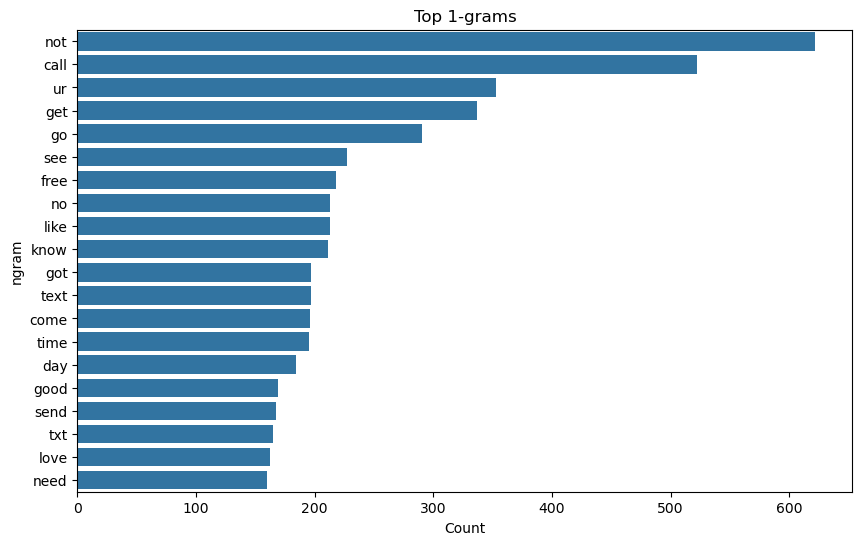

In [12]:
draw_ngram(all_word, 1) # unigrams mais comuns

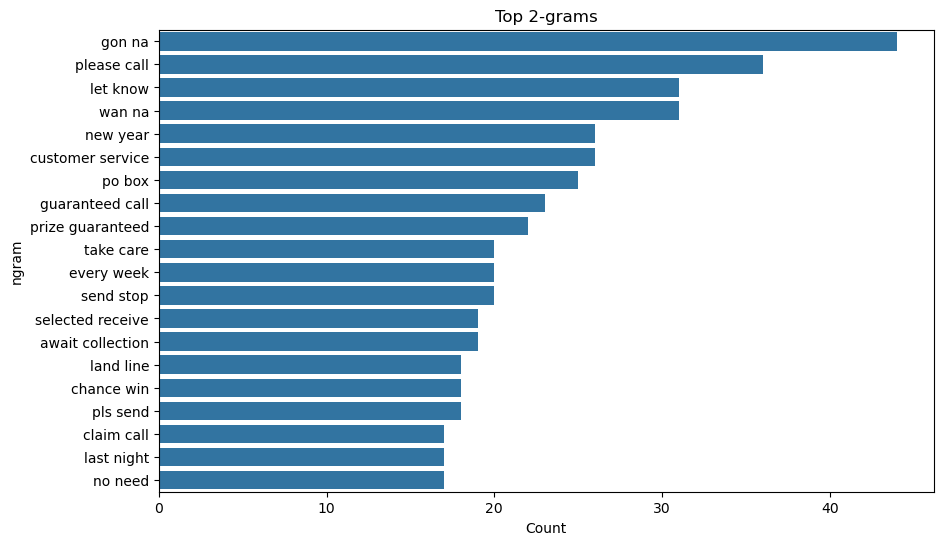

In [13]:
draw_ngram(all_word, 2) # bigrams mais comuns

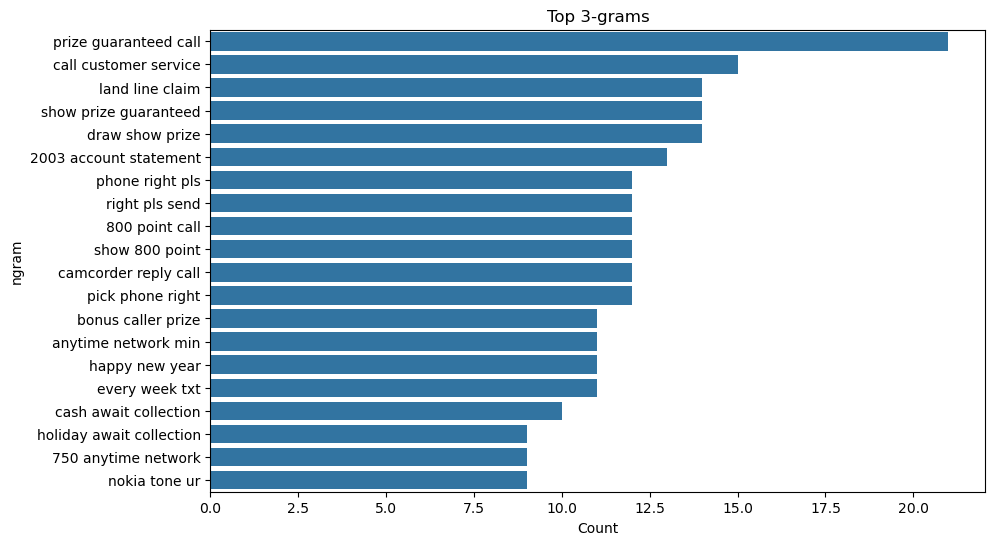

In [14]:
draw_ngram(all_word, 3) # trigrams mais comuns



## Model Training

#### TF-IDF para Vetorizar o Dataframa

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer  # transformar o texto em uma matriz de características 
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,5))  
df_tfidf = tfidf.fit_transform(preprocessed_lemma).toarray()

In [16]:
df_tfidf.shape 

(5572, 5000)

In [17]:
# matriz de características com 5000 colunas, cada coluna representa um n-grama e o valor é a frequência do n-grama no texto.

df_tfidf = pd.DataFrame(df_tfidf, columns=tfidf.get_feature_names_out())
df_tfidf

,0800,0800 542,08000839402,08000930705,08000930705 delivery,08001950382,08002986906,0808,0808 145,0808 145 4742,...,yr prize call customer,yr prize call customer service,yun,yuo,yup,yup ok,yup thk,zed,ìï,ìï got
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Model Training

In [18]:
X = df_tfidf
Y = df['v1'].map({'ham': 0, 'spam': 1}) # mapeia a coluna v1 para 0 e 1, onde ham é 0 e spam é 1

import xgboost as xgb # import  
from sklearn.model_selection import train_test_split # import para dividir o dataset em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) # 20% teste e 80% treino
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss') 

In [19]:
# import para métricas de avaliação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report 

results_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])

def evaluate(real, pred): # avaliar o modelo com as métricas de avaliação e arredondar os resultados para 2 casas decimais
    accuracy = accuracy_score(real, pred)
    precision = precision_score(real, pred)
    recall = recall_score(real, pred)
    f1 = f1_score(real, pred, average='weighted')
    return round(accuracy, 2), round(precision, 2), round(recall, 2), round(f1, 5) # arredondar o f1 para 5 casas decimais para melhor visualização

def print_evaluate(model_name, real, pred): # imprimir as métricas de avaliação e adicionar os resultados ao dataframe de resultados
    accuracy, precision, recall, f1 = evaluate(real, pred)
    print('__________________________________')
    print('Model:', model_name)
    print('Accuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)
    print('__________________________________')
    results_df.loc[len(results_df)] = [model_name, accuracy, precision, recall, f1]
    print(classification_report(real, pred, target_names=['ham', 'spam']))

In [20]:
xgb_model.fit(X_train, y_train) # treinar o modelo com os dados de treino
y_pred = xgb_model.predict(X_test) # fazer previsões com os dados de teste

c:\Users\Miguel Caldas\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


__________________________________
Model: XGBoost
Accuracy: 0.97
Precision: 0.97
Recall: 0.8
F1: 0.96826
__________________________________
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       0.97      0.80      0.88       150

    accuracy                           0.97      1115
   macro avg       0.97      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



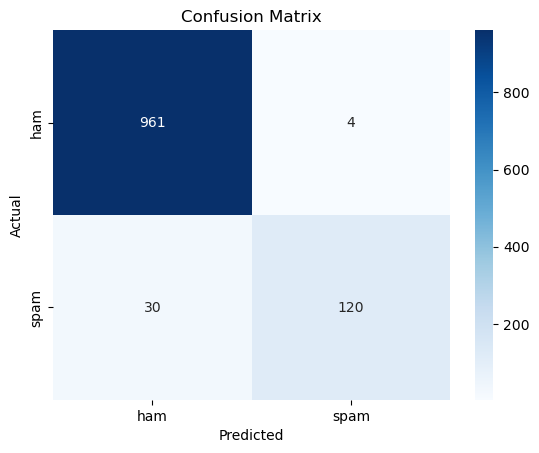

In [21]:
print_evaluate('XGBoost', y_test, y_pred) # avaliar o modelo e imprimir os resultados   

cm = confusion_matrix(y_test, y_pred) # matriz de confusão

sns.heatmap(cm, annot=True, fmt = 'd', cmap="Blues",  # heatmap da matriz de confusão
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# accuracy: 0.98
# precision: 0.98
# recall: 0.8
# F1: 0.96826

In [29]:
#using SVM
from sklearn.svm import SVC
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

__________________________________
Model: SVM
Accuracy: 0.98
Precision: 0.96
Recall: 0.86
F1: 0.97612
__________________________________
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       965
        spam       0.96      0.86      0.91       150

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



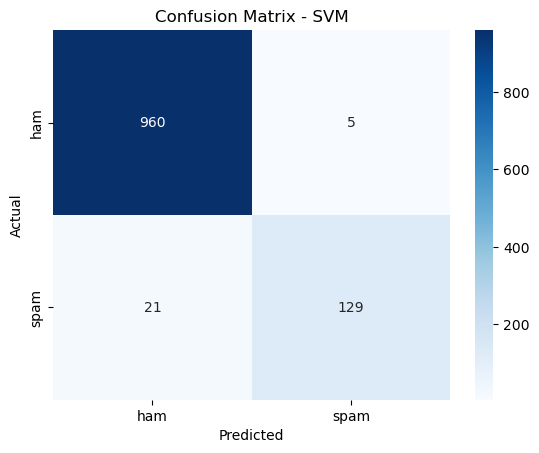

In [30]:
print_evaluate("SVM", y_test, y_pred_svm)

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [31]:
# using balanced SVM
from sklearn.svm import SVC
svm_clf_balanced = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_clf_balanced.fit(X_train, y_train)
y_pred_svm_balanced = svm_clf_balanced.predict(X_test)

In [ ]:
print_evaluate("Balanced SVM", y_test, y_pred_svm_balanced)

cm_svm_balanced = confusion_matrix(y_test, y_pred_svm_balanced)
sns.heatmap(cm_svm_balanced, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"],
            yticklabels=["ham", "spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced SVM")
plt.show()